Dante Angel
INST414
9/25/26
Module 1 Assignment

Question:
Which video game developers are the most connected when it comes to other developers working on the same game? 

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
# All import statements needed to make this code operate

In [3]:
df = pd.read_csv("game_info.csv") # To read the files first
df.head() # to get the first five columns of the table. A small preview.

,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17T11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06T23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22T13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28T22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17T13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


In [4]:
df.shape # To see how many rows and columns are in this table

(474417, 27)

In [5]:
df.info() # Gets the types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474417 entries, 0 to 474416
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    474417 non-null  int64  
 1   slug                  474415 non-null  object 
 2   name                  474414 non-null  object 
 3   metacritic            4733 non-null    float64
 4   released              450218 non-null  object 
 5   tba                   474417 non-null  bool   
 6   updated               474417 non-null  object 
 7   website               65041 non-null   object 
 8   rating                474417 non-null  float64
 9   rating_top            474417 non-null  int64  
 10  playtime              474417 non-null  int64  
 11  achievements_count    474417 non-null  int64  
 12  ratings_count         474417 non-null  int64  
 13  suggestions_count     474417 non-null  int64  
 14  game_series_count     474417 non-null  int64  
 15  

In [6]:
df_network = df[["id", "name", "developers"]].copy()

df_network = df_network.dropna(subset = ["developers"])# I am dropping NaN values

df_network["developers"] = df_network["developers"].str.split(r"\|\|")

df_network.head()

,id,name,developers
0,1,D/Generation HD,[West Coast Software]
1,10,G Prime Into The Rain,[Soma Games]
2,100,Land Sliders,[Prettygreat Pty]
3,1000,Pixel Gear,"[Oasis Games, Geronimo Interactive]"
4,10000,Gods and Idols,[Viking Tao]


In [7]:
g = nx.Graph()

In [8]:
for developers in df_network["developers"]:
    developers = list(set(developers))
    
    for developer in developers:
        g.add_node(developer)
        
    for developer_1, developer_2 in combinations(developers, 2):
        g.add_edge(developer_1, developer_2)

In [9]:
# Number of Nodes and Edges

print(f"Number of nodes: {g.number_of_nodes()}")

print(f"Number of edges: {g.number_of_edges()}")

Number of nodes: 215115
Number of edges: 68929


In [10]:
degree = dict(g.degree())

degree_df = pd.DataFrame(degree.items(), columns = ["developer", "degree"])

degree_df = degree_df.sort_values("degree", ascending = False)

degree_df.head(10)

,developer,degree
5771,Sony Interactive Entertainment,253
6133,SEGA,184
2330,Electronic Arts,160
10943,AI Factory,126
10987,1C Wireless,106
10948,Banana & Co.,105
4156,Konami Digital Entertainment,103
23253,Nintendo,96
10961,Brainium Studios,95
10983,Green Panda Games,94


In [11]:
# Degree Centrality
degree_cent = nx.degree_centrality(g)

centrality_df = pd.DataFrame(degree_cent.items(), columns = ["developer", "degree_cent"])

centrality_df = centrality_df.sort_values("degree_cent", ascending = False)

centrality_df.head(10)

,developer,degree_cent
5771,Sony Interactive Entertainment,0.001176
6133,SEGA,0.000855
2330,Electronic Arts,0.000744
10943,AI Factory,0.000586
10987,1C Wireless,0.000493
10948,Banana & Co.,0.000488
4156,Konami Digital Entertainment,0.000479
23253,Nintendo,0.000446
10961,Brainium Studios,0.000442
10983,Green Panda Games,0.000437


In [12]:
top_3_nodes = centrality_df.head(3)

top_3_nodes # The three most important nodes

,developer,degree_cent
5771,Sony Interactive Entertainment,0.001176
6133,SEGA,0.000855
2330,Electronic Arts,0.000744


In [13]:
dev_results = degree_df.merge(centrality_df, on = "developer")

dev_results = dev_results.sort_values("degree_cent", ascending = False)

dev_results.head(10)

# Now I added degree into the column again

,developer,degree,degree_cent
0,Sony Interactive Entertainment,253,0.001176
1,SEGA,184,0.000855
2,Electronic Arts,160,0.000744
3,AI Factory,126,0.000586
4,1C Wireless,106,0.000493
5,Banana & Co.,105,0.000488
6,Konami Digital Entertainment,103,0.000479
7,Nintendo,96,0.000446
8,Brainium Studios,95,0.000442
9,Green Panda Games,94,0.000437


In [14]:
for developer in top_3_nodes["developer"]:
    print("\nDeveloper:", developer)
    
    games = df_network[df_network["developers"].apply(lambda x : developer in x)]
    
    print(f"Number of games: {len(games)}")
    print(games["name"].head(10).to_list())


Developer: Sony Interactive Entertainment
Number of games: 647
['DRIVECLUB VR', 'FINAL FANTASY VI', 'Here They Lie', 'RIGS Mechanized Combat League', 'Hustle Kings VR', 'PlayStation VR Demo Disc', 'Stifled', 'PlayStation VR Worlds', 'Super Stardust Ultra VR', 'The Playroom VR']

Developer: SEGA
Number of games: 513
['Hatsune Miku: VR Future Live', 'Judgment: Apocalypse Survival Simulation', 'Sonic Dash', 'Hatsune Miku: Project DIVA X', 'Ecco: The Tides of Time', 'Decap Attack', 'Columns III', 'Bio-Hazard Battle', 'Alien Storm', 'Super Thunder Blade']

Developer: Electronic Arts
Number of games: 316
['The Simpsons: Tapped Out', 'Star Wars: Galaxy of Heroes', 'FIFA 17', 'EA SPORTS NHL 17', 'Plants vs. Zombies HD', 'STAR WARS Battlefront 2 (2005)', 'Madden NFL 17', 'Real Racing 2', 'SimCity BuildIt', 'Flight Control HD']


In [15]:
top_devs = set(top_3_nodes["developer"])
neighbors = set()

for developer in top_devs:
    neighbors.update(g.neighbors(developer))
    
nodes = top_devs.union(neighbors)

visual_graph = g.subgraph(nodes).copy()

print("Number of nodes:", visual_graph.number_of_nodes())
print("Number of edges:", visual_graph.number_of_edges())

Number of nodes: 541
Number of edges: 2041


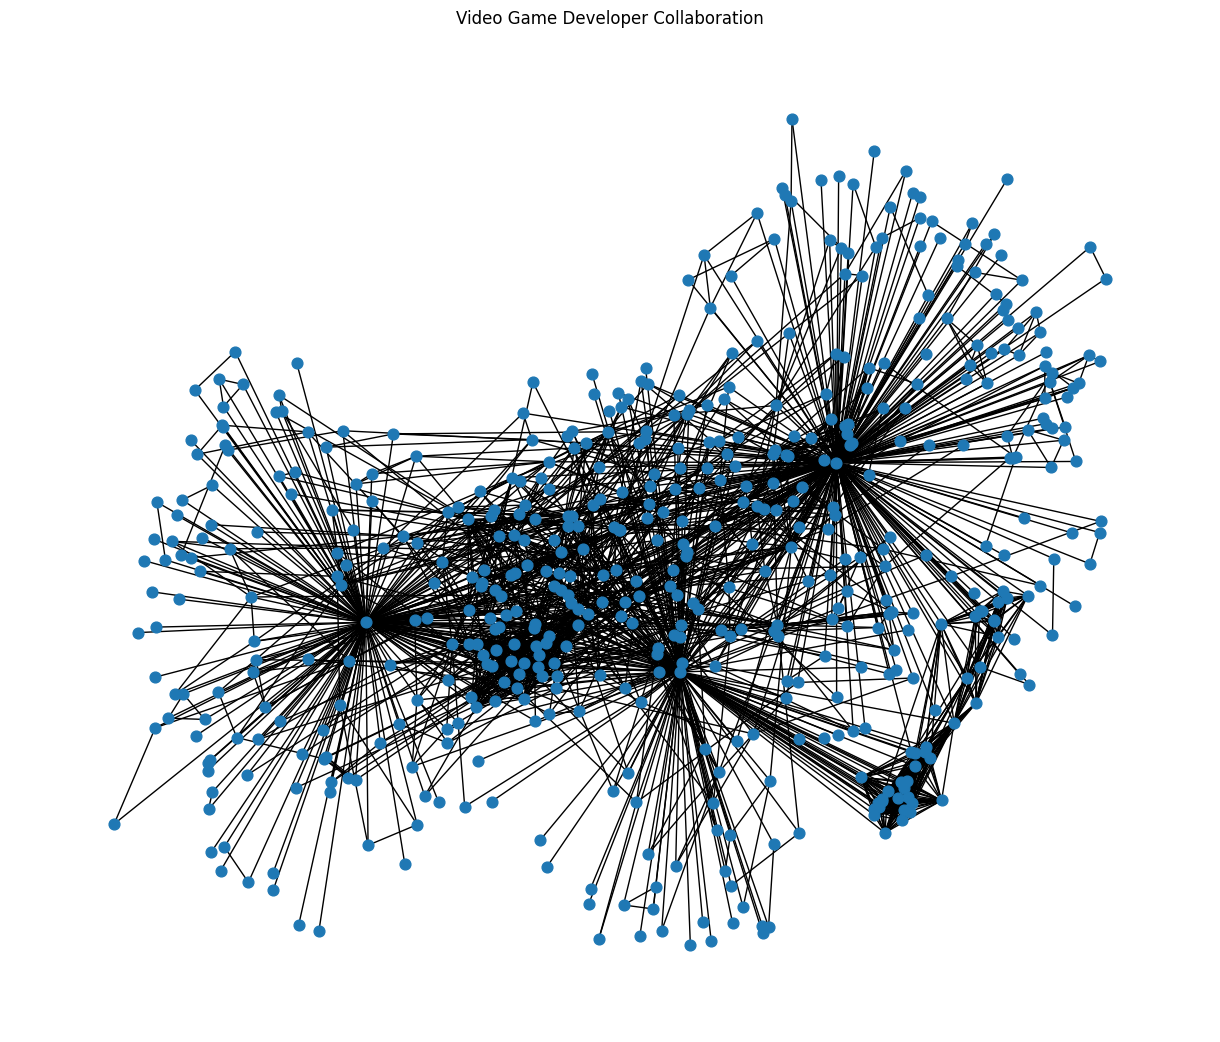

In [16]:
plt.figure(figsize = (12, 10))

pos = nx.spring_layout(visual_graph, seed = 42)

nx.draw(visual_graph, pos, node_size = 60, with_labels = False)

plt.title("Video Game Developer Collaboration")

plt.show()

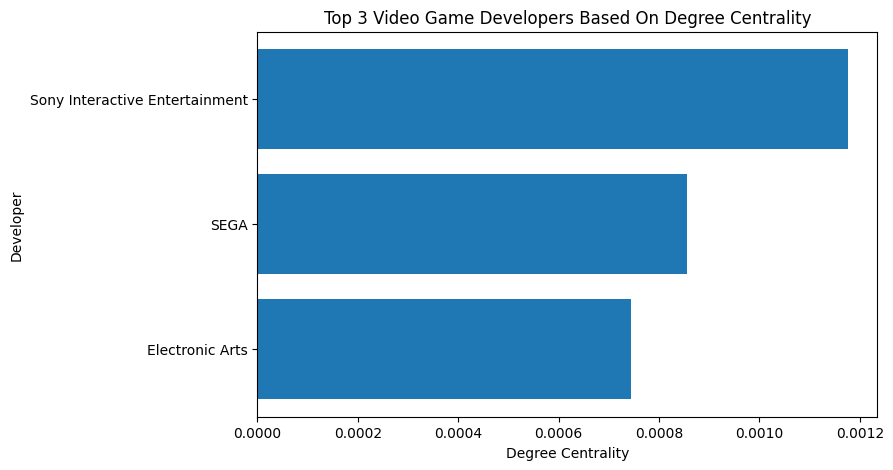

In [17]:
top_3_plot= top_3_nodes.sort_values("degree_cent", ascending = True)

plt.figure(figsize = (8, 5))

plt.barh(top_3_plot["developer"], top_3_plot["degree_cent"])

plt.xlabel("Degree Centrality")

plt.ylabel("Developer")

plt.title("Top 3 Video Game Developers Based On Degree Centrality")

plt.show()

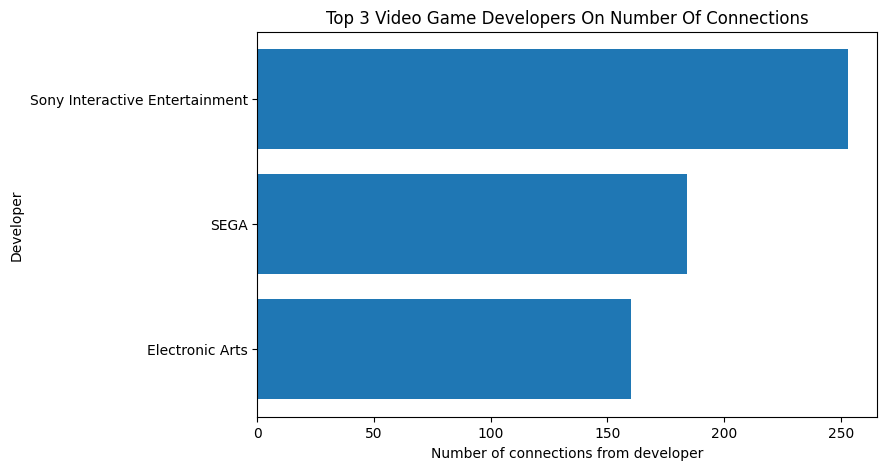

In [18]:
top_3_degrees = dev_results.head(3).sort_values("degree", ascending = True)

plt.figure(figsize = (8, 5))

plt.barh(top_3_degrees["developer"], top_3_degrees["degree"])

plt.xlabel("Number of connections from developer")

plt.ylabel("Developer")

plt.title("Top 3 Video Game Developers On Number Of Connections")

plt.show()

In [19]:
dev_results.to_csv("developer_degree_centrality.csv", index = False)

In [20]:
top_3_nodes.to_csv("top_3_nodes.csv", index = False)

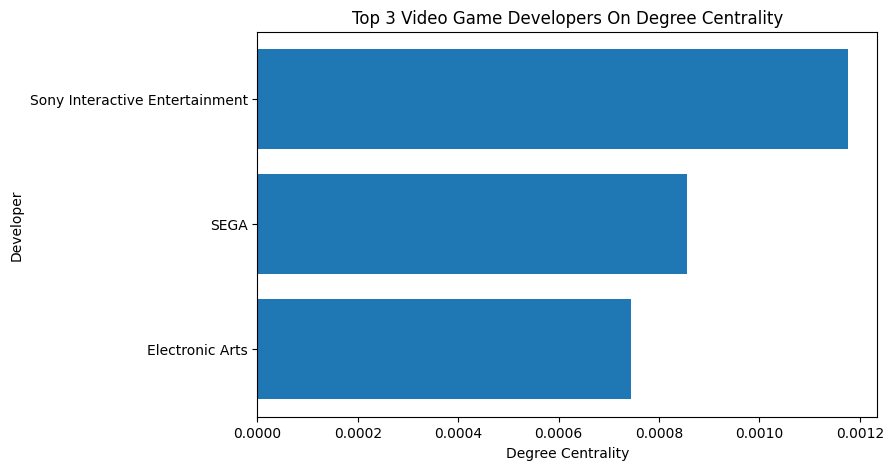

In [21]:
plt.figure(figsize = (8, 5))

plt.barh(top_3_plot["developer"], top_3_plot["degree_cent"])

plt.xlabel("Degree Centrality")

plt.ylabel("Developer")

plt.title("Top 3 Video Game Developers On Degree Centrality")

plt.savefig("top_3_degree_centrality.png", bbox_inches = "tight")

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'bbox'

<Figure size 800x500 with 0 Axes>

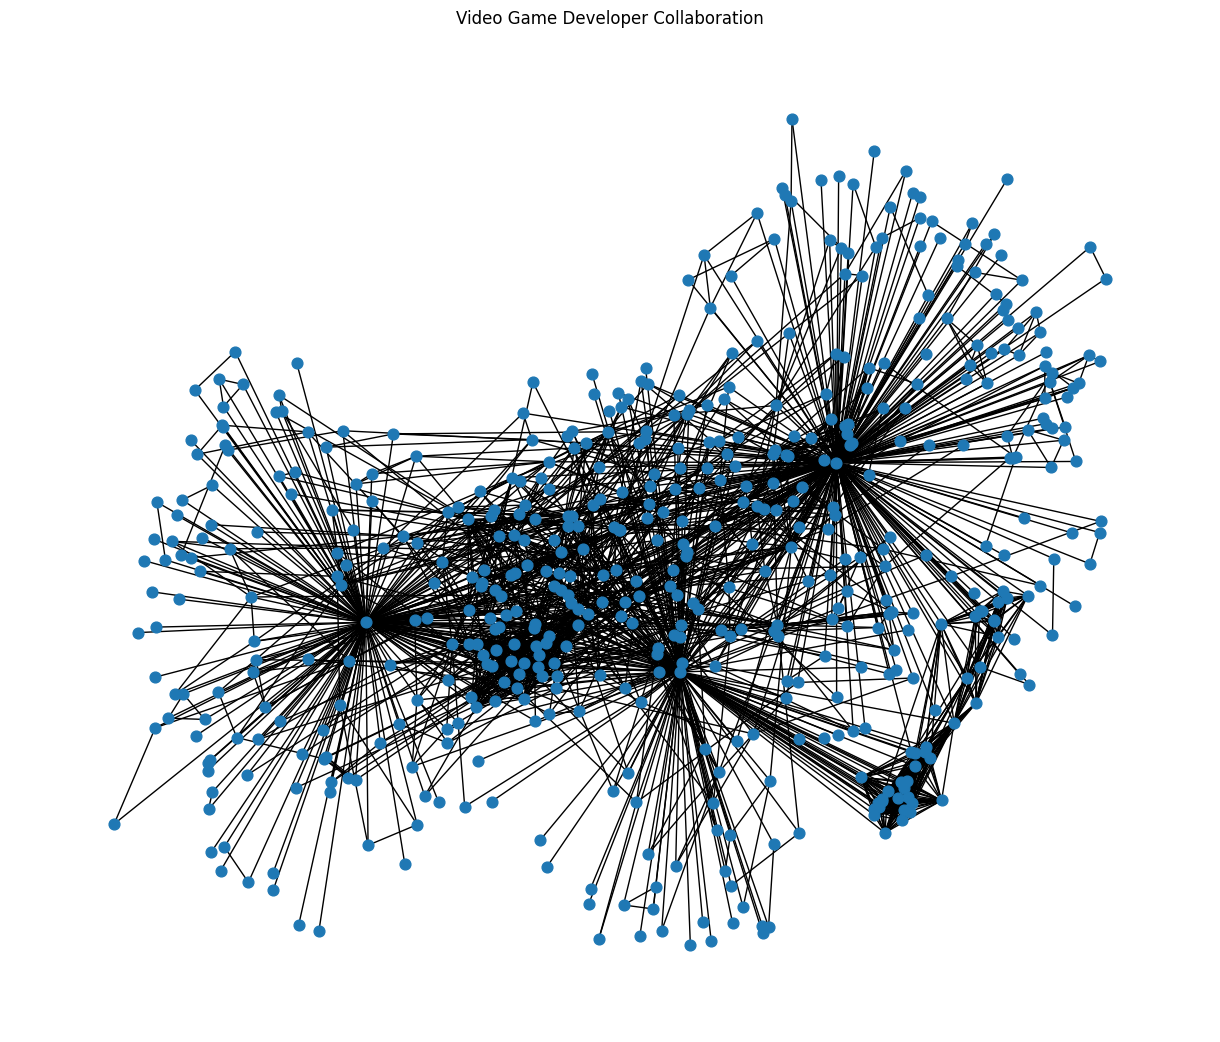

In [ ]:
plt.figure(figsize = (8, 5))

plt.figure(figsize = (12, 10))

pos = nx.spring_layout(visual_graph, seed = 42)

nx.draw(visual_graph, pos, node_size = 60, with_labels = False)

plt.title("Video Game Developer Collaboration")


plt.savefig("node_visulaization.png")